In [1]:
!pip install lightgbm xgboost

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [4]:
df=pd.read_csv("C:\\Users\\gagan\\Downloads\\diabetes (4).csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
print(df.shape)

print(df.info())

print(df.describe())

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479  

In [6]:
cols=['Glucose',
      'BloodPressure',
      'SkinThickness',
      'Insulin',
      'BMI']

df[cols]=df[cols].replace(0,np.nan)

print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [7]:
cols=['Glucose',
      'BloodPressure',
      'SkinThickness',
      'Insulin',
      'BMI']

df[cols]=df[cols].replace(0,np.nan)

print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [8]:
imputer=SimpleImputer(strategy='median')

df[cols]=imputer.fit_transform(df[cols])

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [9]:
imputer=SimpleImputer(strategy='median')

df[cols]=imputer.fit_transform(df[cols])

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


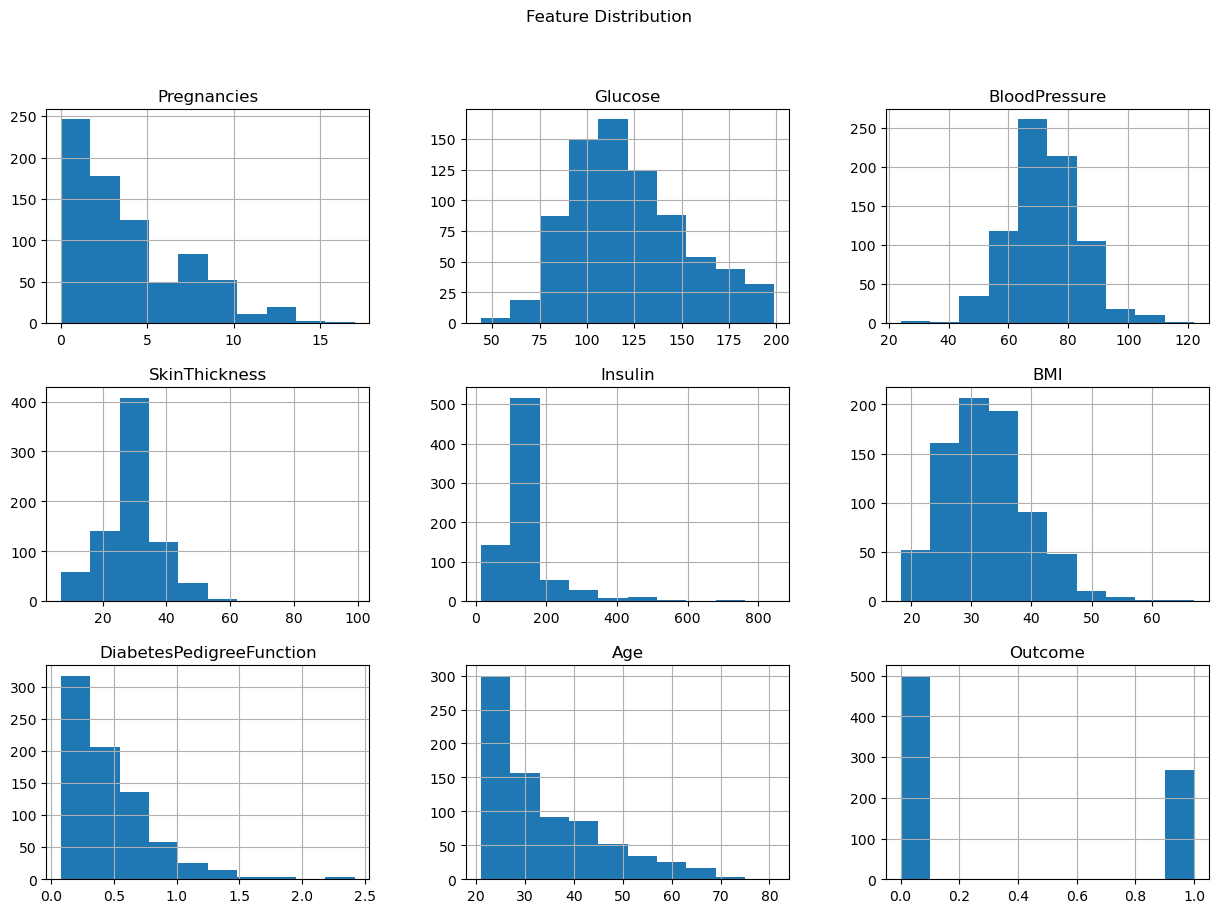

In [10]:
df.hist(figsize=(15,10))

plt.suptitle("Feature Distribution")

plt.show()

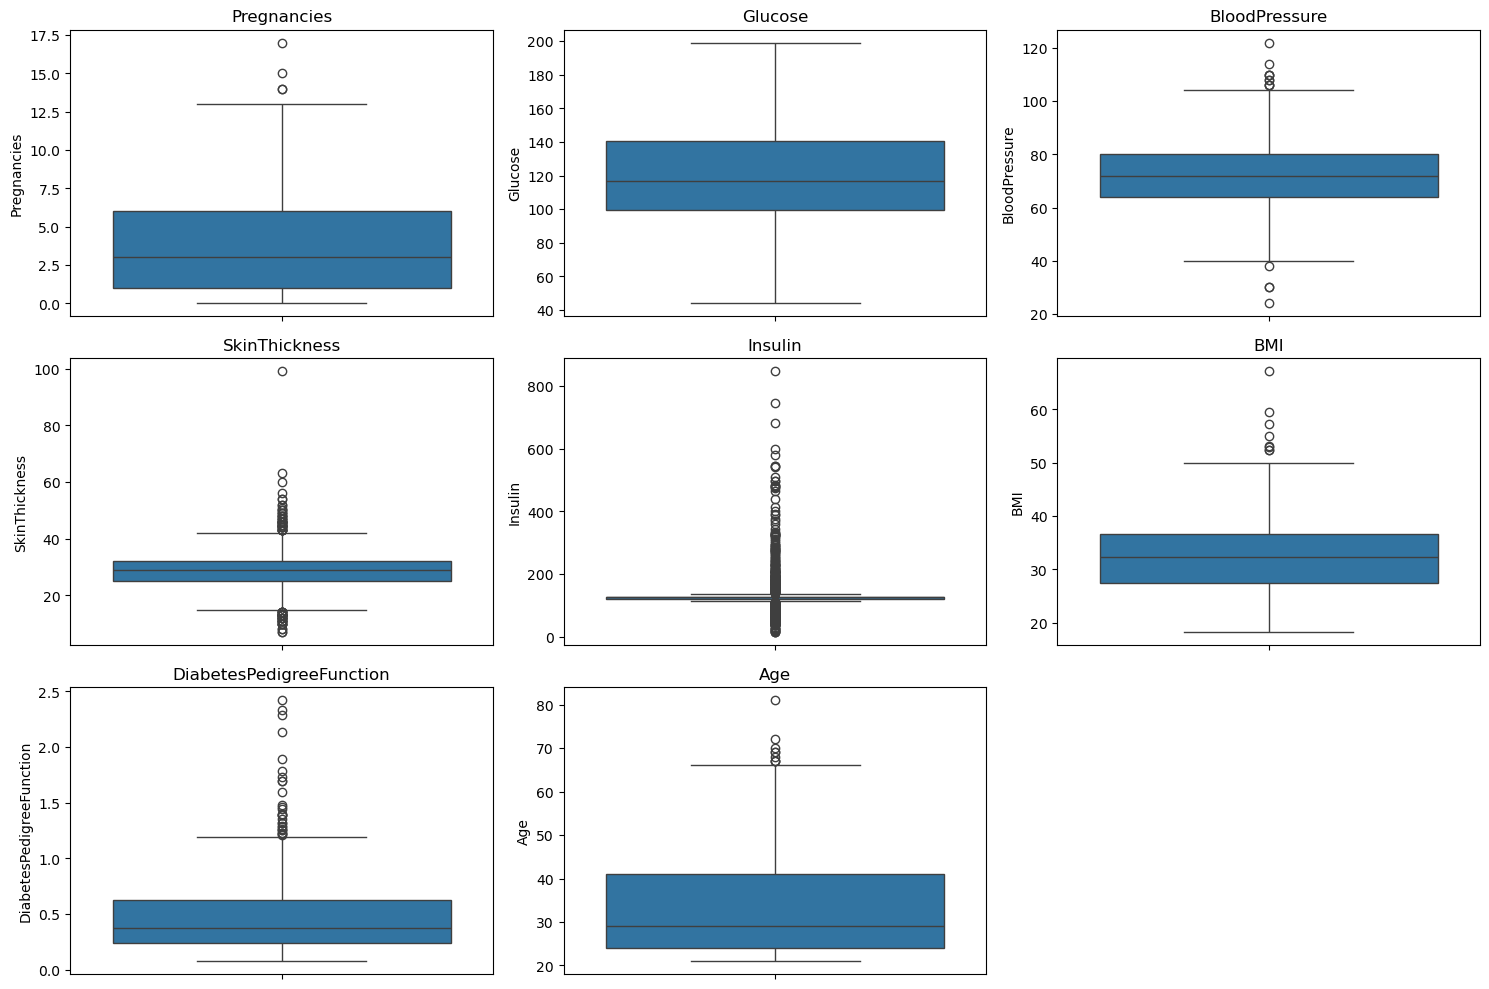

In [11]:
plt.figure(figsize=(15,10))

for i,col in enumerate(df.columns[:-1],1):

    plt.subplot(3,3,i)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

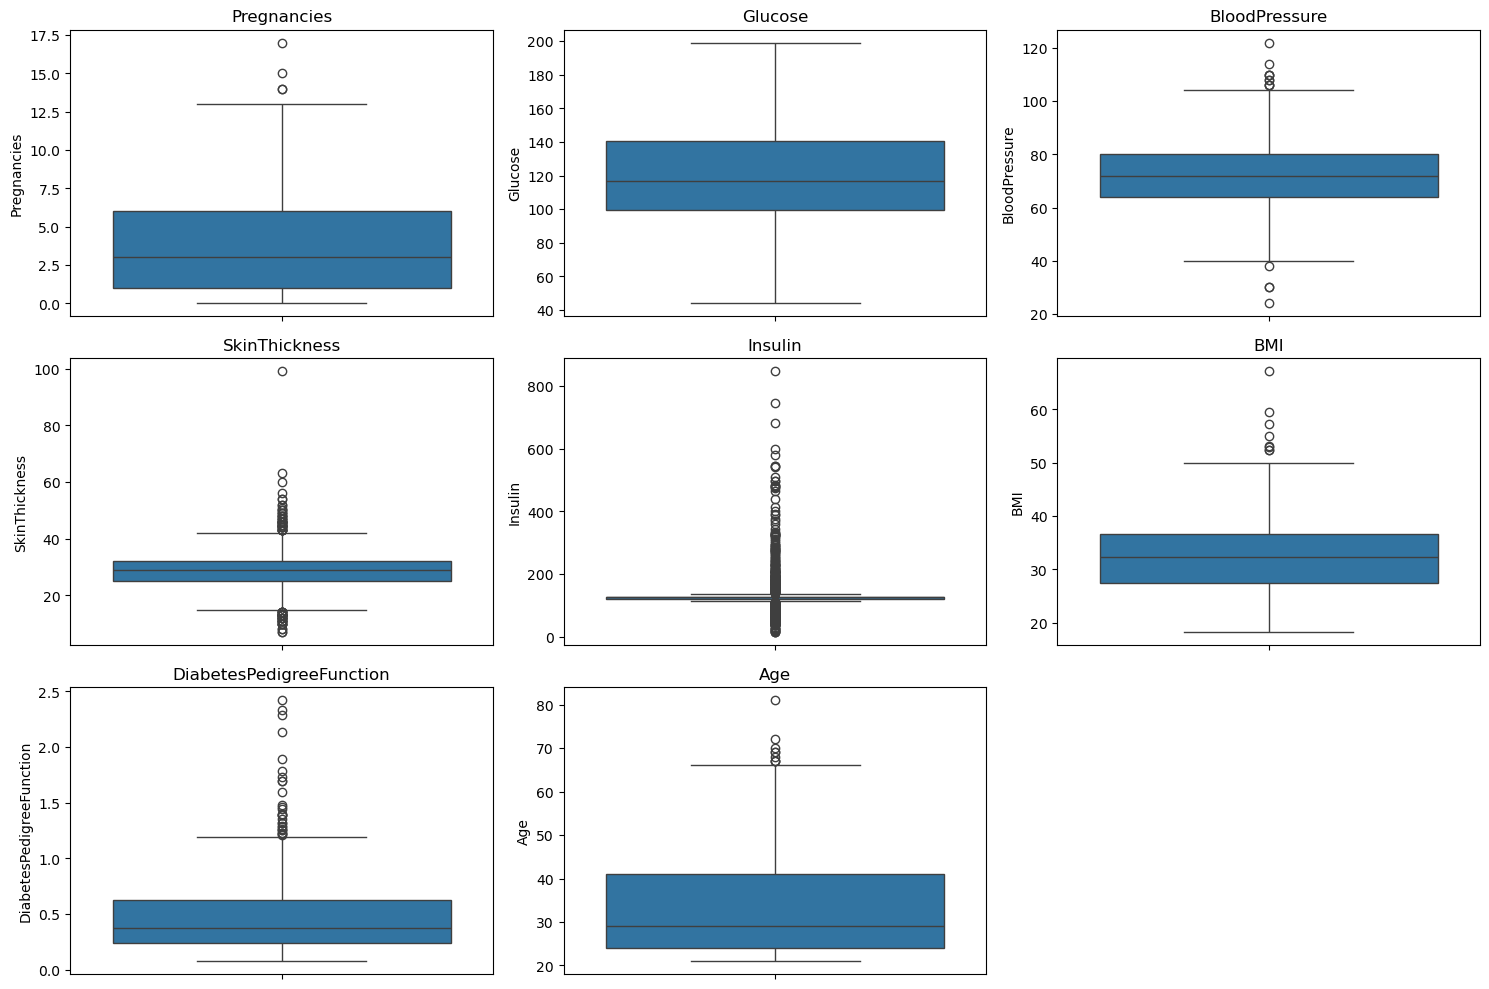

In [12]:
plt.figure(figsize=(15,10))

for i,col in enumerate(df.columns[:-1],1):

    plt.subplot(3,3,i)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

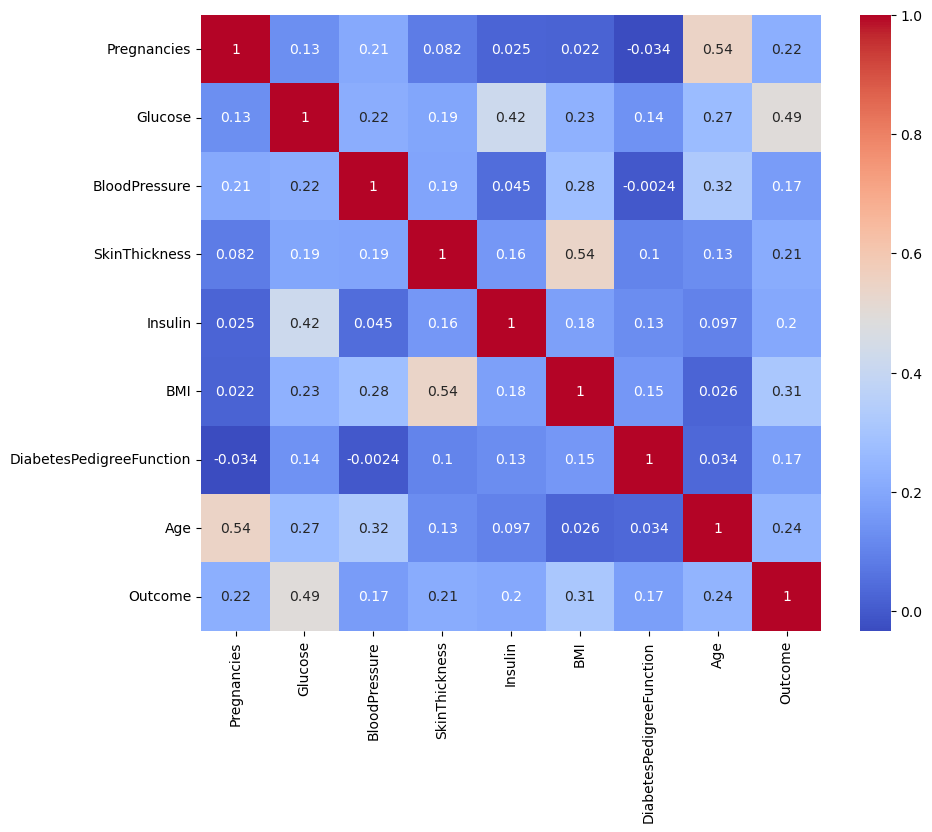

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(
df.corr(),
annot=True,
cmap='coolwarm'
)

plt.show()

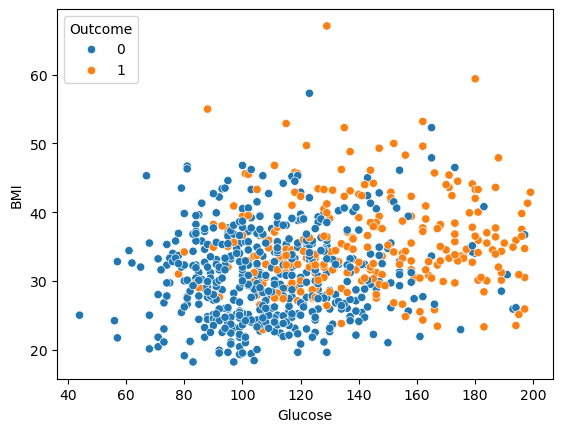

In [14]:
sns.scatterplot(
x='Glucose',
y='BMI',
hue='Outcome',
data=df
)

plt.show()

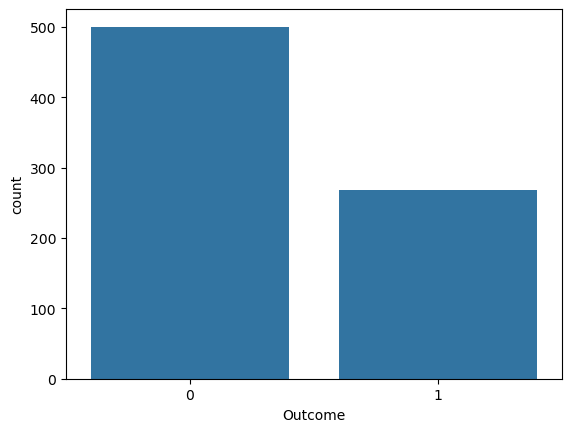

In [15]:
sns.countplot(
x='Outcome',
data=df
)

plt.show()

In [16]:
X=df.drop("Outcome",axis=1)

y=df["Outcome"]

X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

print(X_train.shape)

print(X_test.shape)

(614, 8)
(154, 8)


In [17]:
lgb=LGBMClassifier(
random_state=42,
verbose=-1
)

lgb.fit(
X_train,
y_train
)

pred_lgb=lgb.predict(X_test)

In [18]:
print("Accuracy:",
accuracy_score(y_test,pred_lgb))

print("Precision:",
precision_score(y_test,pred_lgb))

print("Recall:",
recall_score(y_test,pred_lgb))

print("F1:",
f1_score(y_test,pred_lgb))

Accuracy: 0.7662337662337663
Precision: 0.68
Recall: 0.6296296296296297
F1: 0.6538461538461539


In [19]:
xgb=XGBClassifier(
random_state=42,
eval_metric='logloss'
)

xgb.fit(
X_train,
y_train
)

pred_xgb=xgb.predict(X_test)

In [20]:
print("Accuracy:",
accuracy_score(y_test,pred_xgb))

print("Precision:",
precision_score(y_test,pred_xgb))

print("Recall:",
recall_score(y_test,pred_xgb))

print("F1:",
f1_score(y_test,pred_xgb))

Accuracy: 0.7597402597402597
Precision: 0.673469387755102
Recall: 0.6111111111111112
F1: 0.6407766990291263


In [21]:
print(
cross_val_score(
lgb,
X,
y,
cv=5
).mean()
)

print(
cross_val_score(
xgb,
X,
y,
cv=5
).mean()
)

0.7526355996944232
0.7448433919022154


In [22]:
parameters={

'n_estimators':[50,100],

'learning_rate':[0.01,0.1],

'max_depth':[3,5,7]

}

grid=GridSearchCV(

LGBMClassifier(verbose=-1),

parameters,

cv=3

)

grid.fit(
X_train,
y_train
)

print(grid.best_params_)

{'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100}


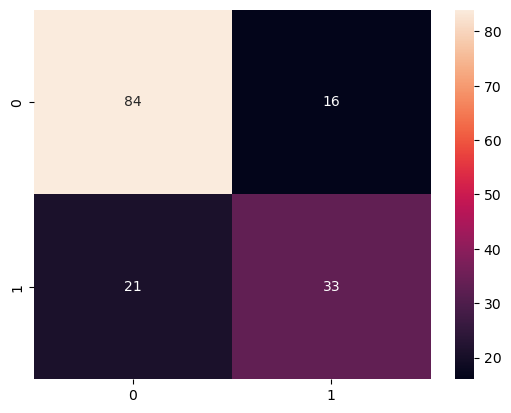

In [23]:
cm=confusion_matrix(
y_test,
pred_xgb
)

sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.show()

In [24]:
print(classification_report(
y_test,
pred_xgb
))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



          Accuracy  Precision    Recall        F1
LightGBM  0.766234   0.680000  0.629630  0.653846
XGBoost   0.759740   0.673469  0.611111  0.640777


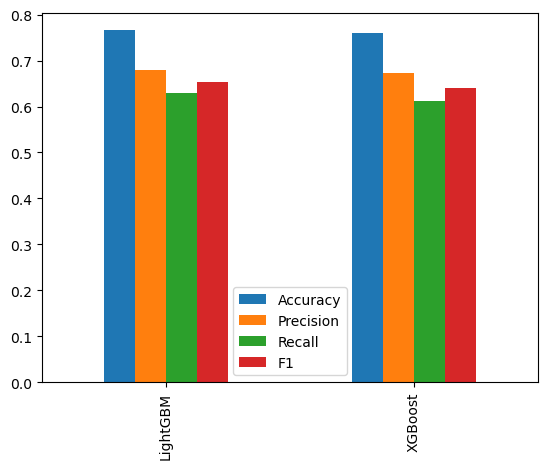

In [25]:
comparison=pd.DataFrame({

'Accuracy':[accuracy_score(y_test,pred_lgb),
accuracy_score(y_test,pred_xgb)],

'Precision':[precision_score(y_test,pred_lgb),
precision_score(y_test,pred_xgb)],

'Recall':[recall_score(y_test,pred_lgb),
recall_score(y_test,pred_xgb)],

'F1':[f1_score(y_test,pred_lgb),
f1_score(y_test,pred_xgb)]

},

index=['LightGBM','XGBoost'])

print(comparison)

comparison.plot(
kind='bar'
)

plt.show()

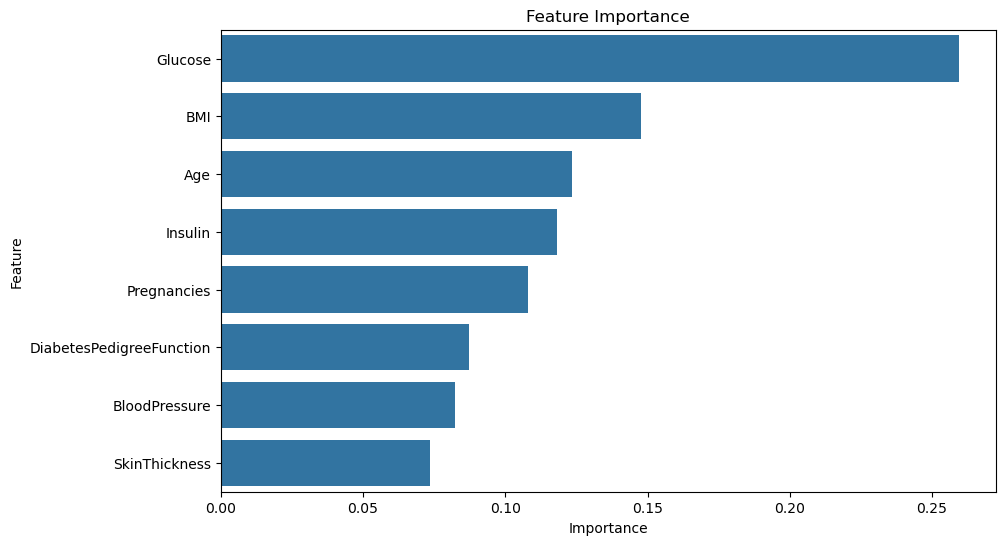

In [26]:
feature_imp=pd.DataFrame({

'Feature':X.columns,

'Importance':xgb.feature_importances_

})

feature_imp=feature_imp.sort_values(
by='Importance',
ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
x='Importance',
y='Feature',
data=feature_imp
)

plt.title(
"Feature Importance"
)

plt.show()

REPORT

Objective:
To compare LightGBM and XGBoost algorithms using Diabetes dataset.

EDA:
Dataset exploration was performed using histograms, boxplots, scatterplots and heatmaps.

Preprocessing:
Missing values were identified and handled using median imputation.

Model Building:
LightGBM and XGBoost models were trained using train-test split.

Evaluation:
Accuracy, Precision, Recall and F1 score were used.

Optimization:
Cross validation and GridSearchCV improved model performance.

Comparative Analysis:
XGBoost achieved strong predictive performance while LightGBM trained efficiently.

Practical implication:
These models can assist in early diabetes prediction in healthcare systems.